# PDoS

Projected electronic density of state versus energy


In [1]:
# Graphene-BC₃ (Hollow)

from vmatplot.PDoS import extract_pdos, extract_segment_pdos

PBE_total = extract_pdos("4_PDoS_PBE/E_Graphene-BC3_Hollow_K25")
PBE_B     = extract_segment_pdos("4_PDoS_PBE/E_Graphene-BC3_Hollow_K25", 1, 2)
PBE_C_top = extract_segment_pdos("4_PDoS_PBE/E_Graphene-BC3_Hollow_K25", 3, 8)
PBE_C_bot = extract_segment_pdos("4_PDoS_PBE/E_Graphene-BC3_Hollow_K25", 9, 16)

HSE_total = extract_pdos("4_PDoS_HSE06/E_Graphene-BC3_Hollow")
HSE_B     = extract_segment_pdos("4_PDoS_HSE06/E_Graphene-BC3_Hollow", 1, 2)
HSE_C_top = extract_segment_pdos("4_PDoS_HSE06/E_Graphene-BC3_Hollow", 3, 8)
HSE_C_bot = extract_segment_pdos("4_PDoS_HSE06/E_Graphene-BC3_Hollow", 9, 16)





In [44]:
title_total = "Total PDoS"
title_C_top = "PDoS for Carbon in Graphene"
title_B_BC3 = "PDoS for Boron in BC₃"
title_C_BC3 = "PDoS for Carbon in BC₃"

matters_dir = [
    [title_total, 6, 10,    "HSE06", HSE_total, "PBE", PBE_total],
    [title_C_top, 6, 3,     "HSE06", HSE_C_top, "PBE", PBE_C_top],
    [title_B_BC3, 6, 3,     "HSE06", HSE_B,     "PBE", PBE_B],
    [title_C_BC3, 6, 3,     "HSE06", HSE_C_bot, "PBE", PBE_C_bot],
    ["blue", 1.0, "solid", "blue", 1.0, "dashed"]
]

test_tot = [
    [title_total, 6, 10,    "HSE06", HSE_total, "PBE", PBE_total],
    ["blue", 1.0, "solid", "blue", 1.0, "dashed"]
]   # Complete

test_sol = [
    [title_total, 6, 10,    "HSE06", HSE_total, "PBE", PBE_total],
    [title_C_top, 6, 3,    "HSE06", HSE_C_top, "PBE", PBE_C_top],
    ["blue", 1.0, "solid", "blue", 1.0, "dashed"]
]

test_duo = [
    [title_total, 6, 10,    "HSE06", HSE_total, "PBE", PBE_total],
    [title_C_top, 6, 3,     "HSE06", HSE_C_top, "PBE", PBE_C_top],
    [title_C_BC3, 6, 3,     "HSE06", HSE_C_bot, "PBE", PBE_C_bot],
    ["blue", 1.0, "solid", "blue", 1.0, "dashed"]
]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


['blue', 'blue']


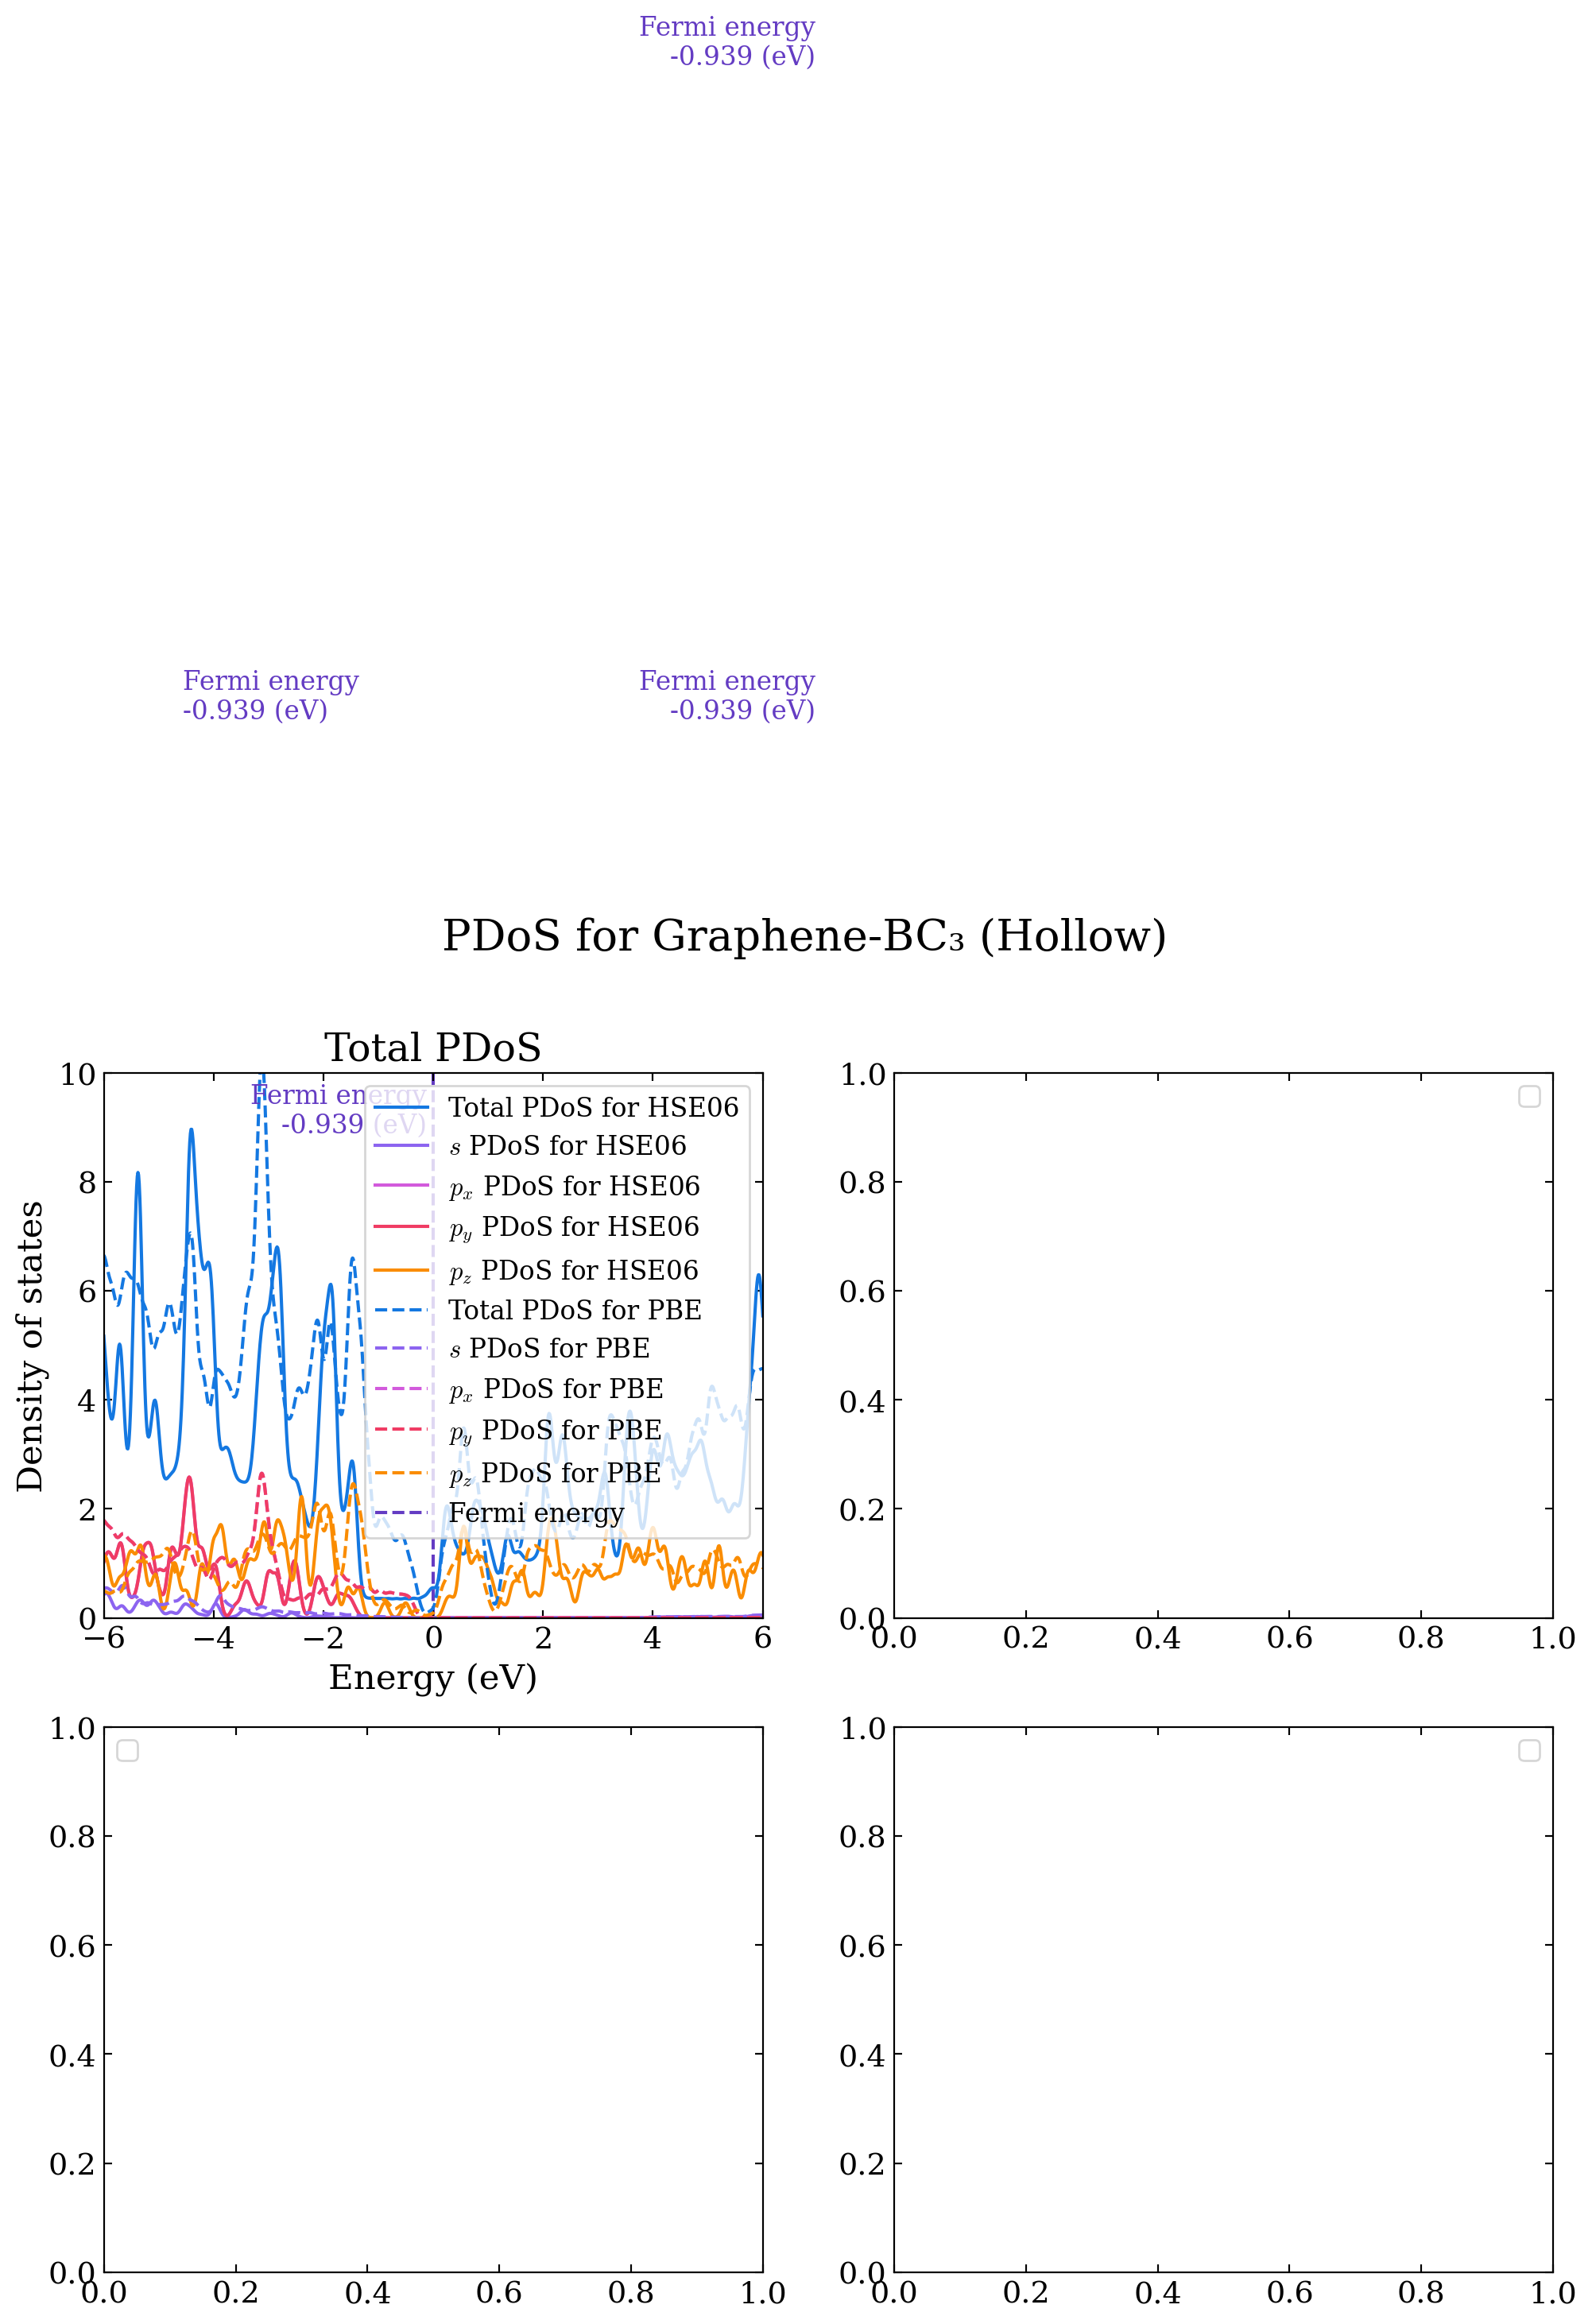

In [51]:
import matplotlib.pyplot as plt
import numpy as np

from vmatplot.output import canvas_setting, color_sampling
from vmatplot.PDoS_plotting import plot_total_segment

def plot_tri_segment_pdos(title, matters_list):

    # Figure settings
    fig_setting = canvas_setting(12, 10)
    params = fig_setting[2]; plt.rcParams.update(params)
    fig, axs = plt.subplots(2, 2, figsize=fig_setting[0], dpi=fig_setting[1])
    axes_element = [axs[0, 0], axs[0, 1], axs[1, 0], axs[1, 1]]

    # Colors calling
    fermi_color = color_sampling("Violet")
    annotate_color = color_sampling("Grey")

    # Materials information
    num_elements = len(matters_list[-1])//3
    matter = matters_list
    efermi = matter[0][4][0]

    # Ranges
    x_range = []
    y_top   = []
    for subplot_index in range(4):
        x_range.append(matter[subplot_index][1])
        y_top.append(matter[subplot_index][2])

    # Data process
    titles = []
    labels = [[], []]
    pdoses = [[], []]
    for subplot_index in range(4):
        titles.append(matter[subplot_index][0])
        for matter_index in range(num_elements):
            labels[matter_index].append(matter[subplot_index][3+2*matter_index])
            pdoses[matter_index].append(matter[subplot_index][4+2*matter_index])
    
    # Style parameters
    color = []
    alpha = []
    lines = []
    for matter_index in range(num_elements):
        color.append(matter[-1][0+3*matter_index])
        alpha.append(matter[-1][1+3*matter_index])
        lines.append(matter[-1][2+3*matter_index])

    print(color)

    fig.suptitle(f"PDoS for {title}", fontsize=fig_setting[3][0])

    label_positions = {0: (1, 0), 1: (0, 0), 2:(1, 1), 3:(0, 1)}

    for supplot_index in range(4):
        ax = axes_element[supplot_index]
        ax.tick_params(direction="in", which="both", top=True, right=True, bottom=True, left=True)
        
    #     pdos_data = pdos_results[supplots_index]
    #     element = elements[supplots_index]

    #     efermi_pdos = pdos_data[0]

        # Total PDoS
        if supplot_index == 0:
            ax.set_title("Total PDoS", fontsize=fig_setting[3][1])
            line_width = 1.00
            for matter_index in range(num_elements):
                current_label = labels[matter_index][0]
                current_pdos  = pdoses[matter_index][0]
                ax.plot(current_pdos[8], current_pdos[6],c=color_sampling(color[matter_index])[1],alpha=alpha[matter_index],ls=lines[matter_index],label=f"Total PDoS for {current_label}",zorder=2)
                ax.plot(current_pdos[8], current_pdos[9],c=color_sampling(color[matter_index])[3],alpha=alpha[matter_index],ls=lines[matter_index],label=f"$s$ PDoS for {current_label}",zorder=2)
                ax.plot(current_pdos[8], current_pdos[12],c=color_sampling(color[matter_index])[4],alpha=alpha[matter_index],ls=lines[matter_index],label=f"$p_x$ PDoS for {current_label}",zorder=2)
                ax.plot(current_pdos[8], current_pdos[10],c=color_sampling(color[matter_index])[5],alpha=alpha[matter_index],ls=lines[matter_index],label=f"$p_y$ PDoS for {current_label}",zorder=2)
                ax.plot(current_pdos[8], current_pdos[11],c=color_sampling(color[matter_index])[6],alpha=alpha[matter_index],ls=lines[matter_index],label=f"$p_z$ PDoS for {current_label}",zorder=2)
            ax.set_xlim(-x_range[0],x_range[0])
            ax.set_ylim(0, y_top[0])
            ax.set_ylabel(r"Density of states")
            ax.set_xlabel(r"Energy (eV)")
            shift = efermi
            ax.axvline(x = efermi-shift, linestyle="--", c=fermi_color[0], alpha=1.00, label="Fermi energy", zorder=1)
            fermi_energy_text = f"Fermi energy\n{efermi:.3f} (eV)"
        if supplot_index == 2:
            ax.text(efermi-shift+x_range[supplot_index]*0.02, y_top[supplot_index]*0.98, fermi_energy_text, fontsize =1.0*12, c=fermi_color[0], rotation=0, va = "top", ha="left")
            ax.legend(loc="upper left")
        else:
            ax.text(efermi-shift-x_range[supplot_index]*0.02, y_top[supplot_index]*0.98, fermi_energy_text, fontsize =1.0*12, c=fermi_color[0], rotation=0, va = "top", ha="right")
            ax.legend(loc="upper right")

    #     x_label, y_label = label_positions[i]
    #     relative_offset = 0.025
    #     if x_label == 0:
    #         ha = "left"; x_label_offset = relative_offset
    #     else:
    #         ha = "right"; x_label_offset = -relative_offset
    #     if y_label == 0:
    #         va = "bottom"; y_label_offset = relative_offset
    #     else:
    #         va = "top"; y_label_offset = -relative_offset

    #     ax.annotate(f"({chr(97 + i)})",
    #                 xy = (x_label + x_label_offset, y_label + y_label_offset),
    #                 xycoords = "axes fraction",
    #                 fontsize = 1.0 * 16,
    #                 ha = ha, va = va,
    #                 bbox = {"facecolor": "white", "alpha": 0.75, "edgecolor": annotate_color[2], "linewidth": 1.5, "boxstyle": "round, pad=0.2"}, zorder=5)

    # plt.tight_layout()

plot_seg_helo_info = "help information"
plot_seg_usage = plot_seg_helo_info
def plot_segment_pdos(*args):
    if len(args) == 1:
        print(plot_seg_helo_info)
    if len(args) == 2:
        if len(args[1]) == 1:
            print("Format error")
            print(plot_seg_usage)
        if len(args[1]) == 2:
            return plot_total_segment(args[0], args[1])
        # if len(args[1]) == 3:
        #     return plot_sol_segment_pdos(args[0], args[1])
        # if len(args[1]) == 4:
        #     return plot_duo_segment_pdos(args[0], args[1])
        if len(args[1]) == 5:
            return plot_tri_segment_pdos(args[0], args[1])

plot_segment_pdos("Graphene-BC₃ (Hollow)", matters_dir)

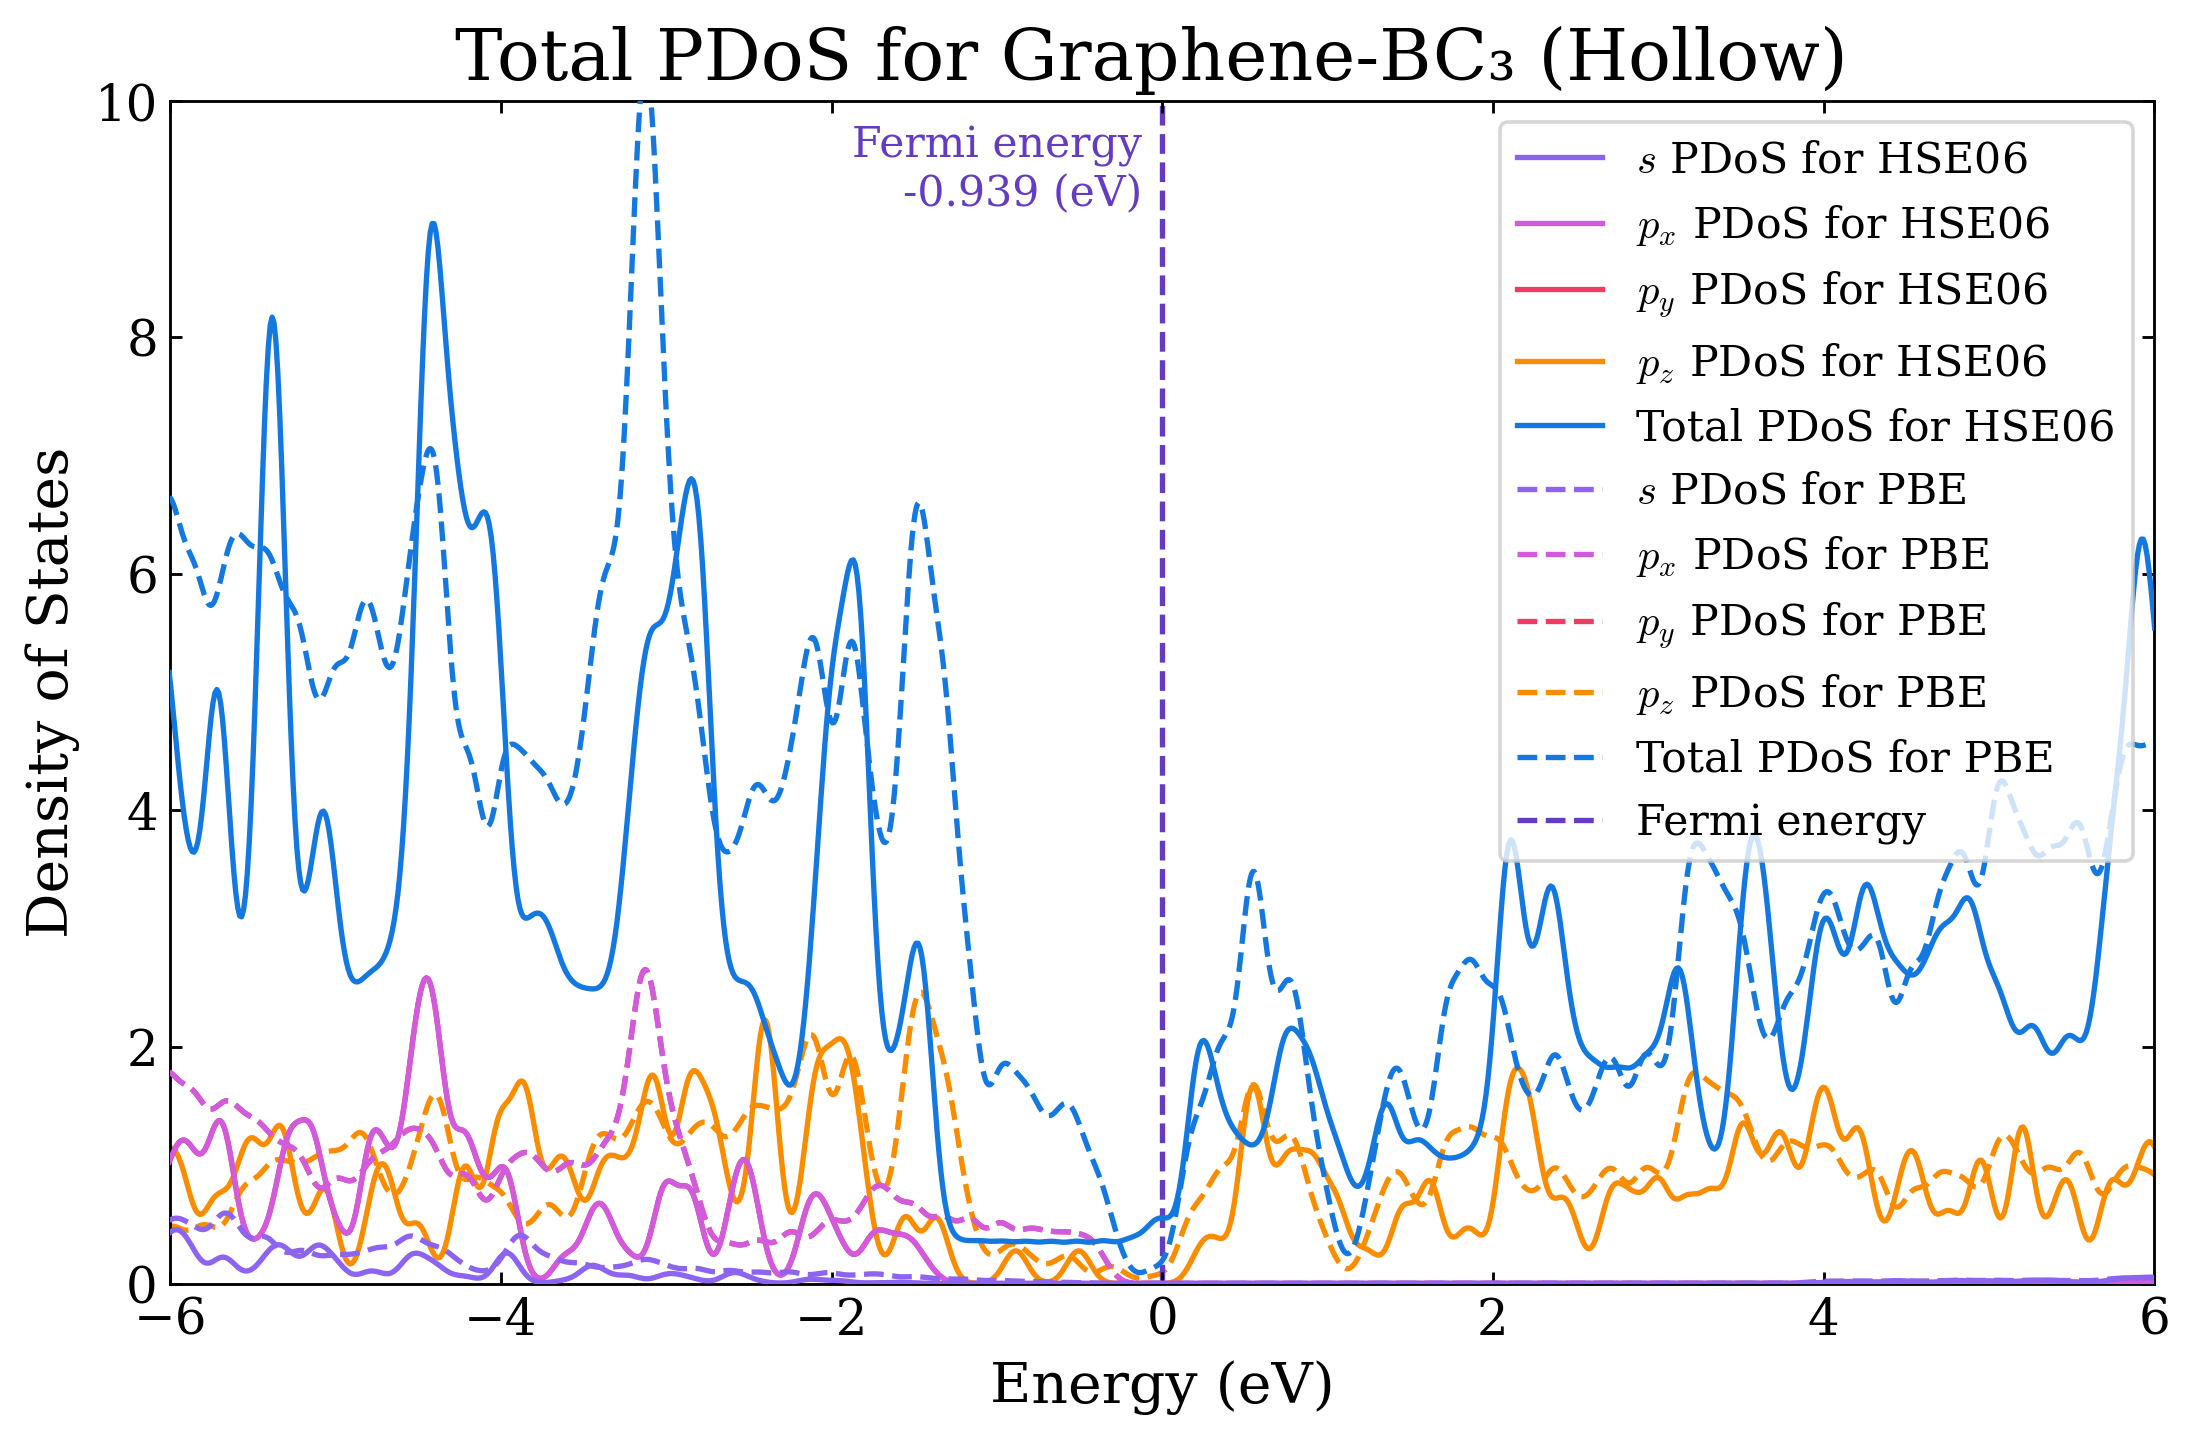

In [15]:
test_tot = [
    [title_total, 6, 10,    "HSE06", HSE_total, "PBE", PBE_total,],
    ["blue", 1.0, "solid", "blue", 1.0, "dashed"]
]   # Complete

plot_segment_pdos("Graphene-BC₃ (Hollow)", test_tot)

In [4]:
# # Graphene-Borophene (Top)

# from vmatplot.PDoS import extract_pdos, extract_segment_pdos
# from vmatplot.PDoS_plotting import *

# PBE_total = extract_pdos("4_PDoS_PBE/F_Graphene-Borophene_Top_K25")
# PBE_B     = extract_segment_pdos("4_PDoS_PBE/F_Graphene-Borophene_Top_K25", 1, 8)
# PBE_C_top = extract_segment_pdos("4_PDoS_PBE/F_Graphene-Borophene_Top_K25", 9, 16)

# HSE_total = extract_pdos("4_PDoS_HSE06/F_Graphene-Borophene_Top_K25")
# HSE_B     = extract_segment_pdos("4_PDoS_HSE06/F_Graphene-Borophene_Top_K25", 1, 8)
# HSE_C_top = extract_segment_pdos("4_PDoS_HSE06/F_Graphene-Borophene_Top_K25", 9, 16)

# title_total = "Total PDoS"
# title_C_top = "PDoS for Carbon in Graphene"
# title_B     = "PDoS for Boron in Borophene"

# matters_dir = [
#     [title_total, 6, 10,    "PBE", PBE_total,   "HSE06", HSE_total],
#     [title_C_top, 6, 4.5,   "PBE", PBE_C_top,   "HSE06", HSE_C_top],
#     [title_B,     6, 4.5,   "PBE", PBE_B,       "HSE06", HSE_B]
# ]

In [5]:
# # Graphene-B₄C₃ (Top)

# from vmatplot.PDoS import extract_pdos, extract_segment_pdos
# from vmatplot.PDoS_plotting import *

# PBE_total = extract_pdos("4_PDoS_PBE/G_Graphene-B4C3_Top_K25")
# PBE_B     = extract_segment_pdos("4_PDoS_PBE/G_Graphene-B4C3_Top_K25", 1, 4)
# PBE_C_top = extract_segment_pdos("4_PDoS_PBE/G_Graphene-B4C3_Top_K25", 5, 7)
# PBE_C_bot = extract_segment_pdos("4_PDoS_PBE/G_Graphene-B4C3_Top_K25", 8, 15)

# HSE_total = extract_pdos("4_PDoS_HSE06/G_Graphene-B4C3_Top")
# HSE_B     = extract_segment_pdos("4_PDoS_HSE06/G_Graphene-B4C3_Top", 1, 4)
# HSE_C_top = extract_segment_pdos("4_PDoS_HSE06/G_Graphene-B4C3_Top", 5, 7)
# HSE_C_bot = extract_segment_pdos("4_PDoS_HSE06/G_Graphene-B4C3_Top", 8, 15)

# title_total  = "Total PDoS"
# title_C_top  = "PDoS for Carbon in Graphene"
# title_B_B4C3 = "PDoS for Boron in B₄C₃"
# title_C_B4C3 = "PDoS for Carbon in B₄C₃"

# matters_dir = [
#     [title_total, 6, 10,    "PBE", PBE_total,   "HSE06", HSE_total],
#     [title_C_top, 6, 10,    "PBE", PBE_C_top,   "HSE06", HSE_C_top],
#     [title_B_B4C3, 6, 3,    "PBE", PBE_B,       "HSE06", HSE_B],
#     [title_C_B4C3, 6, 3,    "PBE", PBE_C_bot,   "HSE06", HSE_C_bot]
# ]
